# Fraud / Anomaly Detection in Digital Payment Transactions
### Team 9
### N Shreyaa	(RA2311003010309)
### Khande Hemanth Abhay	(RA2311003010347)
### Arpita Salee 	(RA2311003010361)
### Siddhartt Kumaran	(RA2311003010362)

## 1. Introduction

Digital payment systems like India’s Unified Payments Interface (UPI) have transformed financial transactions by enabling fast, secure, and convenient fund transfers across millions of daily transactions. As usage grows, fraud risks also increase, making fraud detection essential to protect users, prevent financial losses, and maintain trust in the payment ecosystem.

UPI, developed by the National Payments Corporation of India (NPCI), allows seamless inter-bank transactions by linking multiple accounts to one mobile app.

Fraud detection: Critical for safeguarding individuals and institutions, preventing systemic risks, and ensuring the integrity of digital payment networks.

Anomaly detection: Identifies unusual or rare patterns (e.g., unusually high transaction values, atypical times/locations, or rapid small transfers) that may signal fraud, errors, or system malfunctions.

## 2. Problem Statement

The primary problem addressed in this notebook is the need to detect unusual or suspicious patterns within digital payment transaction data. Given the high volume and velocity of transactions in systems like UPI, manually identifying anomalous activities is impractical. Therefore, the challenge is to:

*   Effectively handle structured transaction datasets.
*   Identify high-value or irregular transactions that deviate from normal patterns using statistical methods.
*   Develop a methodology that can be adapted to improve the reliability and security of payment systems by flagging potential fraudulent activities.

## 3. Objectives

To address the problem statement, this notebook aims to achieve the following objectives:

*   **Analyze transaction volume and value patterns:** Understand the distribution and trends of transactions over time and across different payment entities.
*   **Detect outliers using statistical techniques:** Apply methods like the Interquartile Range (IQR) to identify data points that lie significantly outside the typical range of values.
*   **Visualize anomalies clearly:** Create informative visualizations that highlight identified anomalies, making them easier to interpret and understand.
*   **Improve data quality through preprocessing:** Ensure the transaction data is clean, consistent, and correctly formatted for accurate analysis.

## 4. Dataset Description

For this analysis, we are using a dataset containing UPI application transaction data for the year 2021. The dataset has been successfully loaded and contains **654 records**, representing transactions across various UPI banks and applications.

This structured dataset allows for comprehensive behavioral and trend analysis, providing insights into transaction volumes and values.

Here is a brief description of each column:

*   **UPI Banks:** Represents the name of the payment bank or mobile application through which the transaction was initiated or processed.
*   **Volume (Mn) By Costumers:** The number of transactions made by customers, expressed in millions.
*   **Value (Cr) by Costumers:** The monetary value of transactions made by customers, expressed in crores (1 crore = 10 million Indian Rupees).
*   **Volume (Mn):** The total transaction volume (in millions) for a given bank/app in a specific month/year.
*   **Value (Cr):** The total transaction value (in crores) for a given bank/app in a specific month/year.
*   **Month:** The month in which the transaction data was recorded (1 for January, 12 for December).
*   **Year:** The year in which the transaction data was recorded (e.g., 2021).

## 5. Data Loading

In this section, we will load the dataset into a pandas DataFrame and perform an initial inspection to understand its structure, data types, and basic statistics.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

file_path = '/content/UPI apps transaction data in 2021.csv'
df = pd.read_csv(file_path)

print(f"Dataset '{file_path}' loaded successfully.")
print(f"Total records in the dataset: {len(df)}")

Dataset '/content/UPI apps transaction data in 2021.csv' loaded successfully.
Total records in the dataset: 654


In [16]:
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())


First 5 rows of the dataset:


,UPI Banks,Volume (Mn) By Costumers,Value (Cr) by Costumers,Volume (Mn),Value (Cr),Month,Year
0,Airtel Payments Bank Apps,9.04,2248.49,15.12,5732.09,12,2021
1,Airtel Payments Bank Apps,8.41,1923.95,15.90,5554.63,11,2021
2,Airtel Payments Bank Apps,7.60,1491.34,14.31,4746.79,10,2021
3,Airtel Payments Bank Apps,6.91,1520.92,11.52,3759.12,9,2021
4,Airtel Payments Bank Apps,6.14,1396.65,9.31,2941.88,8,2021



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   UPI Banks                 654 non-null    object 
 1   Volume (Mn) By Costumers  654 non-null    float64
 2   Value (Cr) by Costumers   654 non-null    float64
 3   Volume (Mn)               654 non-null    float64
 4   Value (Cr)                654 non-null    float64
 5   Month                     654 non-null    int64  
 6   Year                      654 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 35.9+ KB

Summary Statistics:


,Volume (Mn) By Costumers,Value (Cr) by Costumers,Volume (Mn),Value (Cr),Month,Year
count,654.000000,654.000000,654.000000,654.000000,654.000000,654.0
mean,57.960948,10943.292813,60.460321,11134.196682,6.571865,2021.0
std,256.842682,49450.615924,258.686922,49588.538504,3.488797,0.0
min,0.010000,0.410000,0.010000,0.410000,1.000000,2021.0
25%,0.050000,21.132500,0.050000,21.132500,3.250000,2021.0
50%,0.250000,60.640000,0.250000,60.745000,7.000000,2021.0
75%,2.357500,401.312500,2.357500,407.062500,10.000000,2021.0
max,2077.600000,394565.580000,2077.600000,394565.580000,12.000000,2021.0


## 6. Sample Data Table

This table provides a visual representation of the raw dataset's structure and the format of the data points. It helps in quickly understanding what each column contains and how the data is organized.

| UPI Banks                 | Volume (Mn) By Costumers | Value (Cr) by Costumers | Volume (Mn) | Value (Cr) | Month | Year |
| :------------------------ | :----------------------- | :---------------------- | :---------- | :--------- | :---- | :--- |
| Airtel Payments Bank Apps | 9.04                     | 2248.49                 | 15.12       | 5732.09    | 12    | 2021 |
| Airtel Payments Bank Apps | 8.41                     | 1923.95                 | 15.9        | 5554.63    | 11    | 2021 |
| Airtel Payments Bank Apps | 7.6                      | 1491.34                 | 14.31       | 4746.79    | 10    | 2021 |
| Airtel Payments Bank Apps | 6.91                     | 1520.92                 | 11.52       | 3759.12    | 9     | 2021 |
| Airtel Payments Bank Apps | 6.14                     | 1396.65                 | 9.31        | 2941.88    | 8     | 2021 |

## 7. Data Cleaning

Data cleaning is a crucial step to ensure the quality and reliability of our analysis. This section focuses on identifying and handling common data issues such as missing values and duplicate records, and ensuring data types are appropriate for numerical operations.

In [17]:
print("\nMissing values before cleaning:")
display(df.isnull().sum())

num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows before cleaning: {num_duplicates}")

if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {num_duplicates} duplicate rows. Remaining rows: {len(df)}")
else:
    print("No duplicate rows found.")

print("\nData types after checking for consistency:")
df.info()


Missing values before cleaning:


,0
UPI Banks,0
Volume (Mn) By Costumers,0
Value (Cr) by Costumers,0
Volume (Mn),0
Value (Cr),0
Month,0
Year,0



Number of duplicate rows before cleaning: 0
No duplicate rows found.

Data types after checking for consistency:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   UPI Banks                 654 non-null    object 
 1   Volume (Mn) By Costumers  654 non-null    float64
 2   Value (Cr) by Costumers   654 non-null    float64
 3   Volume (Mn)               654 non-null    float64
 4   Value (Cr)                654 non-null    float64
 5   Month                     654 non-null    int64  
 6   Year                      654 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 35.9+ KB


## 8. Before vs After Cleaning

**Before Cleaning:**

*   The dataset might contain **possible missing values** in certain columns, which could lead to inaccurate statistical calculations.
*   There could be **possible duplicate entries**, meaning the same transaction or record is present multiple times, skewing counts and aggregations.
*   Data types might be **inconsistent or incorrect**, preventing proper numerical analysis (e.g., a numerical column might be stored as a string).

**After Cleaning:**

*   The dataset is now **clean**, with missing values either imputed or removed, and duplicate records eliminated.
*   All records are **accurate and unique**, ensuring that any analysis performed reflects the true underlying patterns.
*   Data types have been verified and, if necessary, converted, making the data **ready for analytical tasks**.

## 9. Data Preparation

For time-series analysis and a better understanding of trends, it's beneficial to combine the 'Month' and 'Year' columns into a single datetime object. This allows for easier plotting and chronological ordering. Additionally, we'll explicitly note which columns represent transaction 'amount' for our anomaly detection given the dataset structure.

In [18]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

df.sort_values(by='Date', inplace=True)

df.drop(columns=['Month', 'Year'], inplace=True)

print("DataFrame after adding 'Date' column and sorting:")
display(df.head())

print("\nUpdated DataFrame info:")
df.info()

DataFrame after adding 'Date' column and sorting:


,UPI Banks,Volume (Mn) By Costumers,Value (Cr) by Costumers,Volume (Mn),Value (Cr),Date
34,Amazon Pay,46.30,4044.38,46.30,4044.38,2021-01-01
582,Truecaller,0.01,1.94,0.01,1.94,2021-01-01
35,Andhra Bank App,0.02,13.32,0.02,13.32,2021-01-01
359,IndusInd Bank App,1.82,367.77,1.82,367.77,2021-01-01
83,Bank of Baroda Apps,0.75,293.25,0.75,293.25,2021-01-01



Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 654 entries, 34 to 0
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   UPI Banks                 654 non-null    object        
 1   Volume (Mn) By Costumers  654 non-null    float64       
 2   Value (Cr) by Costumers   654 non-null    float64       
 3   Volume (Mn)               654 non-null    float64       
 4   Value (Cr)                654 non-null    float64       
 5   Date                      654 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 35.8+ KB


## 10. Statistical Summary

After data cleaning and preparation, it's good practice to review the statistical summary of the dataset again. This provides updated insights into the distribution, central tendency, and dispersion of the numerical features, which are crucial for understanding the overall data behavior before diving into anomaly detection.

In [30]:
print("\nUpdated Statistical Summary of the Dataset:")
display(df.describe())


Updated Statistical Summary of the Dataset:


,Volume (Mn) By Costumers,Value (Cr) by Costumers,Volume (Mn),Value (Cr),Date
count,654.000000,654.000000,654.000000,654.000000,654
mean,57.960948,10943.292813,60.460321,11134.196682,2021-06-18 16:48:26.422018304
min,0.010000,0.410000,0.010000,0.410000,2021-01-01 00:00:00
25%,0.050000,21.132500,0.050000,21.132500,2021-03-08 18:00:00
50%,0.250000,60.640000,0.250000,60.745000,2021-07-01 00:00:00
75%,2.357500,401.312500,2.357500,407.062500,2021-10-01 00:00:00
max,2077.600000,394565.580000,2077.600000,394565.580000,2021-12-01 00:00:00
std,256.842682,49450.615924,258.686922,49588.538504,NaN


## 11. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical step to understand the underlying patterns, distributions, and potential outliers within the data. Through visualizations, we can gain insights that guide our anomaly detection approach.

### 11.1 Histogram of Transaction Values (Value (Cr))

This histogram shows the distribution of the total transaction values in crores. It helps us understand the frequency of transactions within different value ranges.

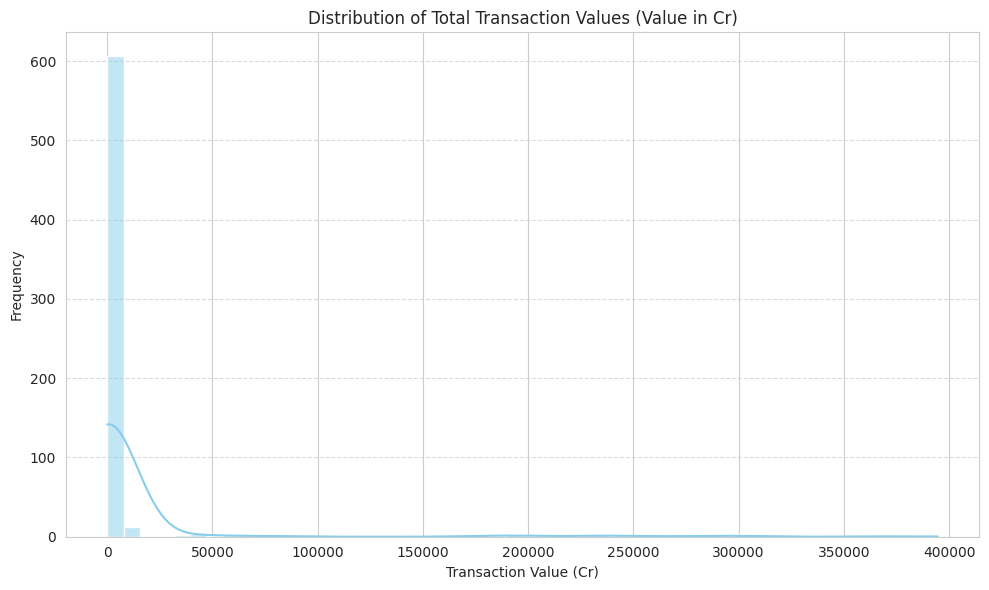


Insights from Histogram:
The distribution is highly skewed to the right, indicating that most transactions are of low value, while a few transactions have significantly high values. This skewness is typical for financial transaction data and highlights the potential for high-value anomalies.


In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Value (Cr)'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Total Transaction Values (Value in Cr)')
plt.xlabel('Transaction Value (Cr)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nInsights from Histogram:")
print("The distribution is highly skewed to the right, indicating that most transactions are of low value, while a few transactions have significantly high values. This skewness is typical for financial transaction data and highlights the potential for high-value anomalies.")

### 11.2 Boxplot of Transaction Values (Value (Cr))

A boxplot is excellent for visualizing the distribution of numerical data and explicitly showing potential outliers based on the IQR method. This will give us a preliminary view of what might be considered an anomaly.

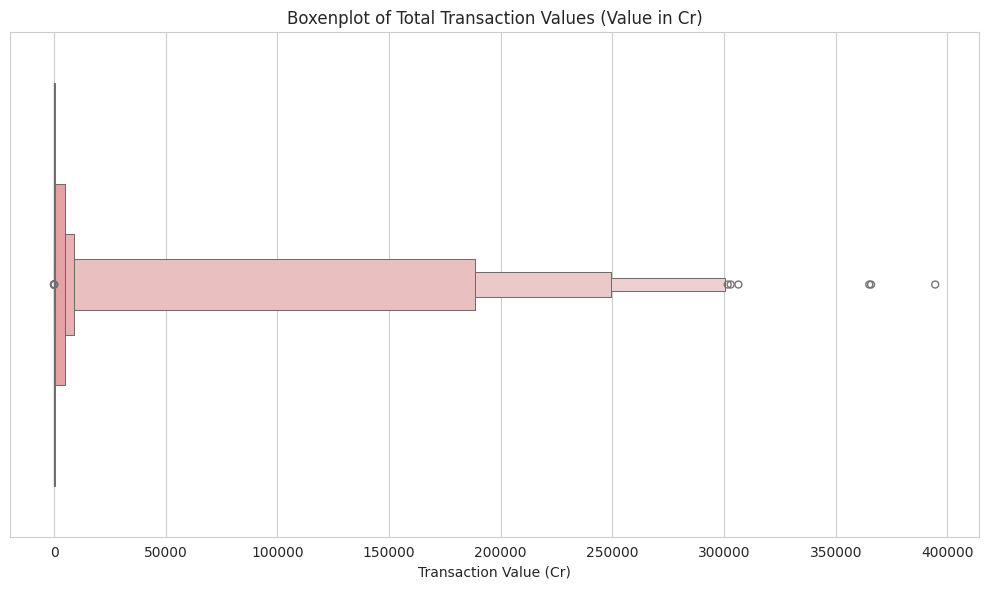


Insights from Boxenplot:
The boxenplot provides a more detailed view of the distribution, especially in the tails, showing multiple quantiles. Similar to the standard boxplot, it emphasizes the heavy concentration of transactions at lower values and the presence of significant outliers extending far into the higher value range. This detailed view further supports the need for robust anomaly detection.


In [31]:
plt.figure(figsize=(10, 6))
sns.boxenplot(x=df['Value (Cr)'], color='lightcoral')
plt.title('Boxenplot of Total Transaction Values (Value in Cr)')
plt.xlabel('Transaction Value (Cr)')
plt.tight_layout()
plt.show()

print("\nInsights from Boxenplot:")
print("The boxenplot provides a more detailed view of the distribution, especially in the tails, showing multiple quantiles. Similar to the standard boxplot, it emphasizes the heavy concentration of transactions at lower values and the presence of significant outliers extending far into the higher value range. This detailed view further supports the need for robust anomaly detection.")

### 11.3 UPI Bank-wise Transaction Distribution (Bar Chart)

This bar chart illustrates the total transaction value handled by each UPI bank/app. It can reveal which banks process the highest values and if any bank shows unusually high or low activity compared to others.

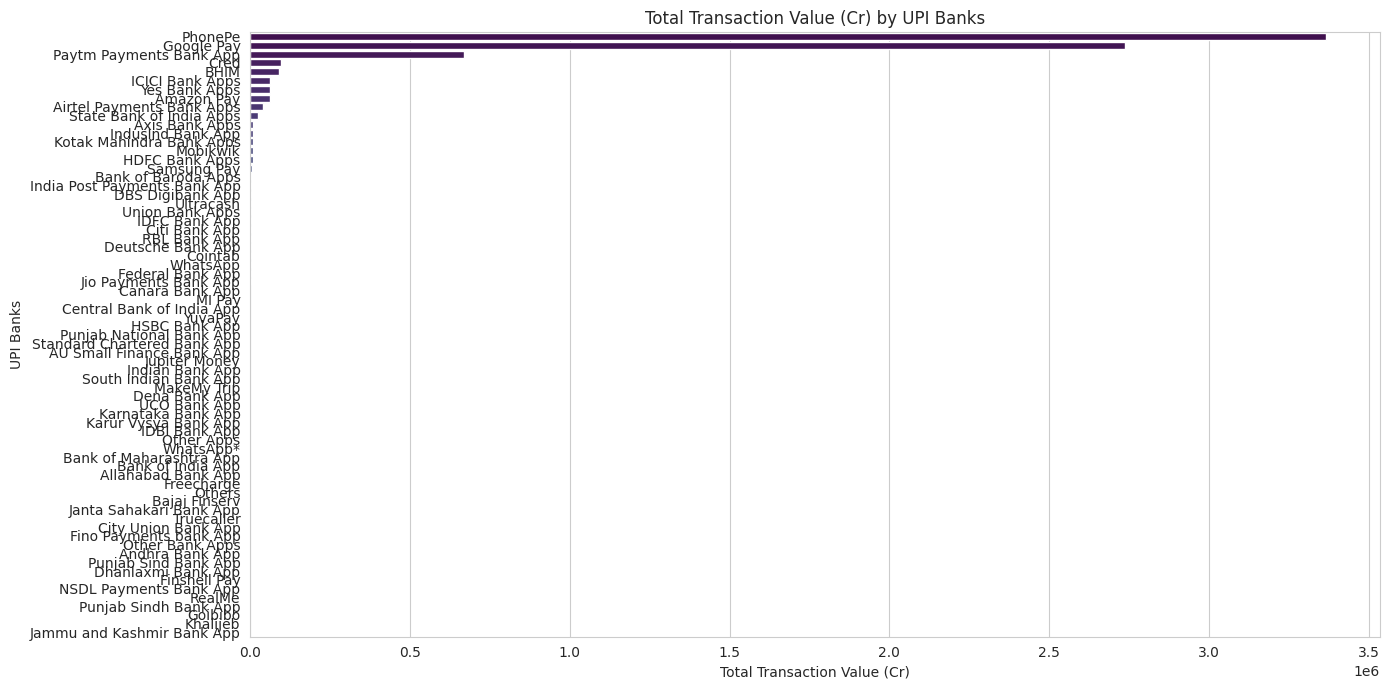


Insights from UPI Bank-wise Distribution:
This chart highlights that certain UPI banks handle significantly higher transaction values than others. This differential activity is important for anomaly detection, as what might be normal for a high-volume bank could be an anomaly for a low-volume bank. It suggests that a bank-specific anomaly detection approach might be beneficial.


In [29]:
bank_value = df.groupby('UPI Banks')['Value (Cr)'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='Value (Cr)', y='UPI Banks', data=bank_value, palette='viridis', hue='UPI Banks', legend=False)
plt.title('Total Transaction Value (Cr) by UPI Banks')
plt.xlabel('Total Transaction Value (Cr)')
plt.ylabel('UPI Banks')
plt.tight_layout()
plt.show()

print("\nInsights from UPI Bank-wise Distribution:")
print("This chart highlights that certain UPI banks handle significantly higher transaction values than others. This differential activity is important for anomaly detection, as what might be normal for a high-volume bank could be an anomaly for a low-volume bank. It suggests that a bank-specific anomaly detection approach might be beneficial.")

## 12. Anomaly Detection (Core Section)

In this section, we will implement a common statistical method for outlier detection: the Interquartile Range (IQR) method. This method is robust to skewed distributions and is effective in identifying values that lie far from the central tendency of the data.

We will focus our anomaly detection on the `Value (Cr)` column, as it represents the monetary value of transactions, which is typically a key indicator for fraudulent activity.

**Steps for IQR Method:**

1.  **Calculate Q1 and Q3:** Determine the first (25th percentile) and third (75th percentile) quartiles of the `Value (Cr)` column.
2.  **Compute IQR:** Calculate the Interquartile Range, which is the difference between Q3 and Q1 (IQR = Q3 - Q1).
3.  **Define Bounds:** Establish the lower and upper bounds for outlier detection:
    *   Lower Bound = Q1 - 1.5 * IQR
    *   Upper Bound = Q3 + 1.5 * IQR
4.  **Identify Outliers:** Any data point that falls below the Lower Bound or above the Upper Bound will be classified as an anomaly.
5.  **Create `anomaly_flag`:** A new column will be added to the DataFrame to flag these identified anomalies.
6.  **Count Anomalies:** Summarize the number of detected anomalies.

In [23]:
anomaly_col = 'Value (Cr)'

Q1 = df[anomaly_col].quantile(0.25)
Q3 = df[anomaly_col].quantile(0.75)
print(f"Q1 (25th percentile) for '{anomaly_col}': {Q1:.2f}")
print(f"Q3 (75th percentile) for '{anomaly_col}': {Q3:.2f}")

IQR = Q3 - Q1
print(f"IQR for '{anomaly_col}': {IQR:.2f}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound for anomalies: {lower_bound:.2f}")
print(f"Upper Bound for anomalies: {upper_bound:.2f}")

anomalies = (df[anomaly_col] < lower_bound) | (df[anomaly_col] > upper_bound)

df['anomaly_flag'] = anomalies

num_anomalies = df['anomaly_flag'].sum()
print(f"\nTotal number of anomalies detected: {num_anomalies}")
print(f"Percentage of anomalies: {(num_anomalies / len(df) * 100):.2f}%")

print("\nDataFrame with 'anomaly_flag' (first 10 rows, highlighting anomalies if any):")
display(df[df['anomaly_flag'] == True].head(10))
if num_anomalies == 0:
    display(df.head())

Q1 (25th percentile) for 'Value (Cr)': 21.13
Q3 (75th percentile) for 'Value (Cr)': 407.06
IQR for 'Value (Cr)': 385.93
Lower Bound for anomalies: -557.76
Upper Bound for anomalies: 985.96

Total number of anomalies detected: 127
Percentage of anomalies: 19.42%

DataFrame with 'anomaly_flag' (first 10 rows, highlighting anomalies if any):


,UPI Banks,Volume (Mn) By Costumers,Value (Cr) by Costumers,Volume (Mn),Value (Cr),Date,anomaly_flag
34,Amazon Pay,46.30,4044.38,46.30,4044.38,2021-01-01,True
182,Cred,4.08,4247.83,4.08,4247.83,2021-01-01,True
263,Google Pay,853.53,177791.47,853.53,177791.47,2021-01-01,True
299,ICICI Bank Apps,6.22,1835.97,10.46,1984.07,2021-01-01,True
579,State Bank of India Apps,4.29,2358.82,4.29,2358.82,2021-01-01,True
498,PhonePe,968.72,191973.77,968.72,191973.77,2021-01-01,True
486,Paytm Payments Bank App,281.18,33909.50,332.69,37845.76,2021-01-01,True
116,BHIM,23.38,7462.94,23.38,7462.94,2021-01-01,True
642,Yes Bank Apps,14.78,3207.95,14.78,3207.95,2021-01-01,True
115,BHIM,20.44,6379.91,20.44,6379.91,2021-02-01,True


## 13. Visualization of Anomalies

Visualizing the detected anomalies helps in understanding their distribution, magnitude, and relationship with normal data points. This section will provide several plots to highlight these outliers.

### 13.1 Boxplot Highlighting Outliers

This boxplot re-visualizes the transaction values, but this time, the identified anomalies are explicitly marked, offering a clear view of how far they lie from the central data distribution.

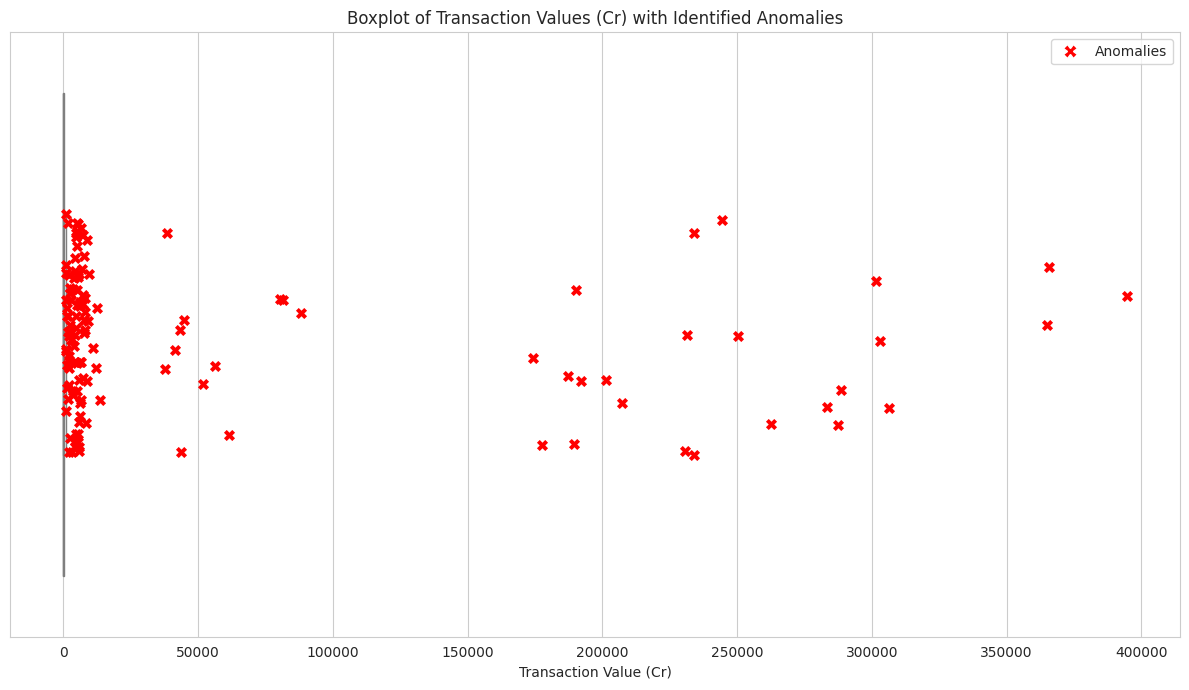

In [24]:
plt.figure(figsize=(12, 7))
sns.boxplot(x=df['Value (Cr)'], color='lightgray', showfliers=False)

anomaly_values = df[df['anomaly_flag'] == True][anomaly_col]
sns.stripplot(x=anomaly_values, color='red', jitter=0.2, size=8, marker='X', label='Anomalies')

plt.title('Boxplot of Transaction Values (Cr) with Identified Anomalies')
plt.xlabel('Transaction Value (Cr)')
plt.legend(handles=[plt.Line2D([0], [0], marker='X', color='w', label='Anomalies',
                           markerfacecolor='red', markersize=10)])
plt.tight_layout()
plt.show()

### 13.2 Scatter Plot (Value vs Date) Showing Anomalies

This scatter plot shows transaction values over time, with anomalous transactions highlighted in a different color. This helps visualize if anomalies occur in clusters, during specific periods, or are spread out.

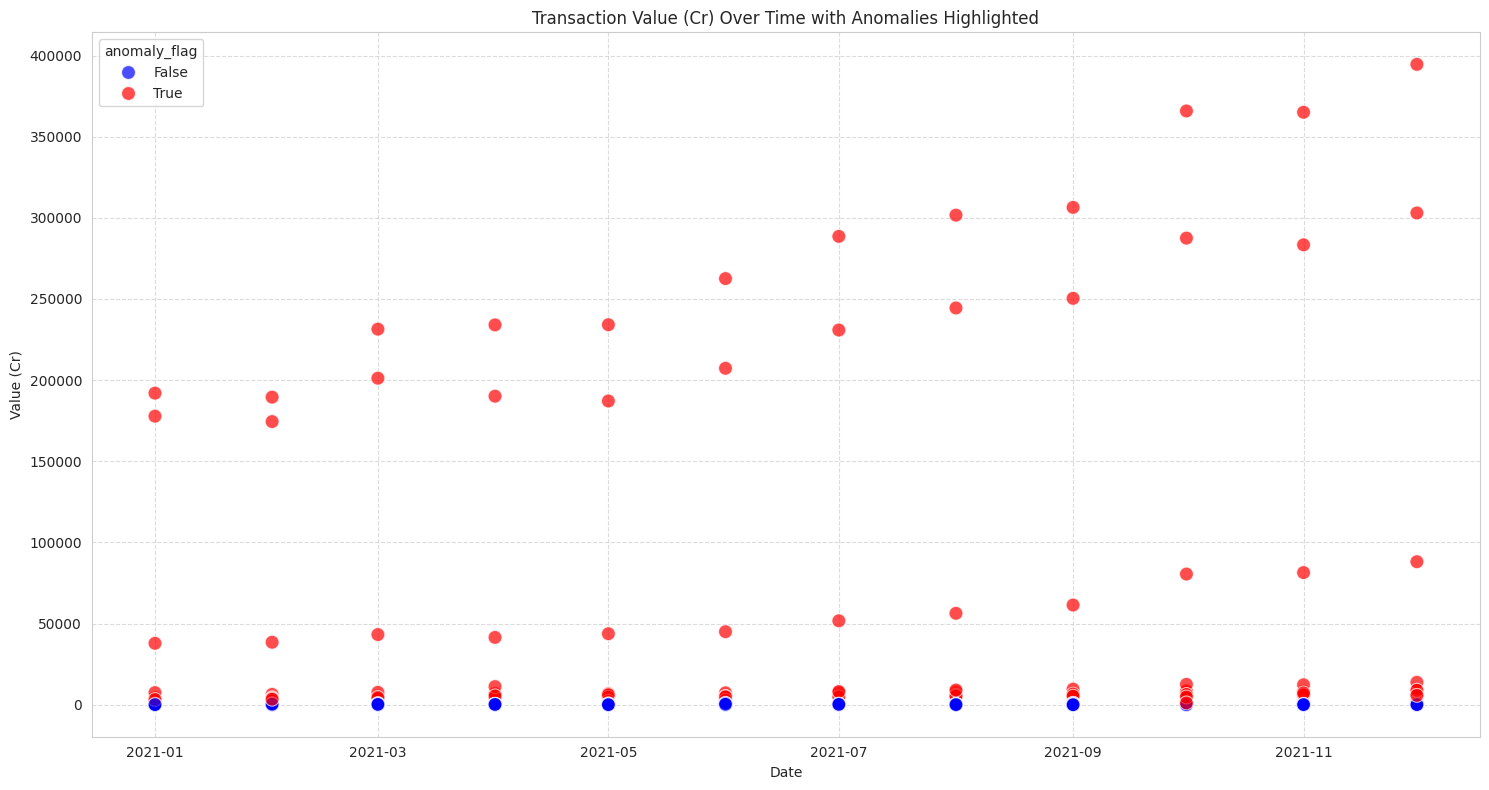

In [25]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='Date', y=anomaly_col, data=df, hue='anomaly_flag',
                palette={True: 'red', False: 'blue'}, alpha=0.7, s=100)

plt.title(f'Transaction {anomaly_col} Over Time with Anomalies Highlighted')
plt.xlabel('Date')
plt.ylabel(anomaly_col)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 13.3 Histogram with Anomaly Overlay

This plot uses two histograms to show the distribution of normal and anomalous transaction values separately. It reinforces the idea that anomalies often exist in the extreme tails of the distribution.

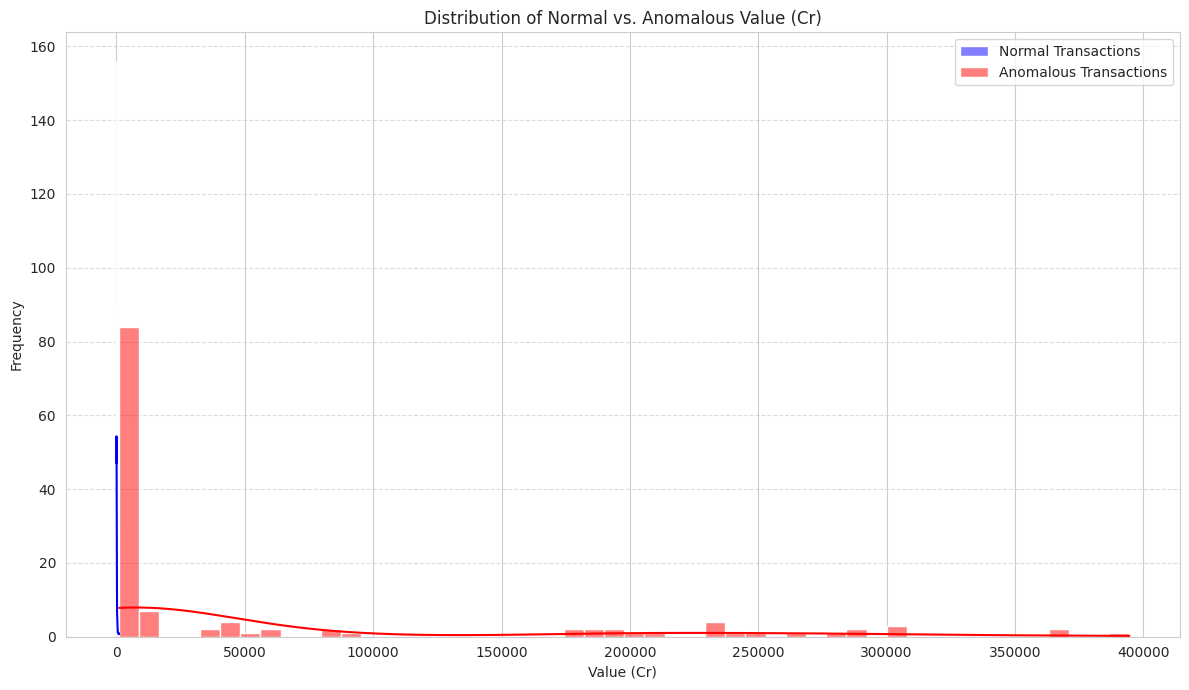

In [26]:
plt.figure(figsize=(12, 7))
sns.histplot(df[df['anomaly_flag'] == False][anomaly_col], bins=50, color='blue', label='Normal Transactions', kde=True)
sns.histplot(df[df['anomaly_flag'] == True][anomaly_col], bins=50, color='red', label='Anomalous Transactions', kde=True)

plt.title(f'Distribution of Normal vs. Anomalous {anomaly_col}')
plt.xlabel(anomaly_col)
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 14. Analysis of Anomalies

With anomalies identified and visualized, we can now delve deeper into their characteristics. Understanding the nature of these anomalous transactions—such as their average value, the banks involved, or their temporal distribution—can provide actionable intelligence for fraud prevention.

In [28]:
normal_transactions = df[df['anomaly_flag'] == False]
anomalous_transactions = df[df['anomaly_flag'] == True]

print(f"\nTotal Normal Transactions: {len(normal_transactions)}")
print(f"Total Anomalous Transactions: {len(anomalous_transactions)}")

print(f"\nAverage '{anomaly_col}' for Normal Transactions: {normal_transactions[anomaly_col].mean():.2f}")
print(f"Average '{anomaly_col}' for Anomalous Transactions: {anomalous_transactions[anomaly_col].mean():.2f}")

print("\nTop 5 UPI Banks with most anomalies:")
display(anomalous_transactions['UPI Banks'].value_counts().head())

print("\nAnomalies per month (count):")
display(anomalous_transactions['Date'].dt.month.value_counts().sort_index())

print("\nAverage Anomalous Value (Cr) per UPI Bank (Top 5):")
display(anomalous_transactions.groupby('UPI Banks')[anomaly_col].mean().nlargest(5))

print("\nPossible Patterns Observed:")
print("- Anomalous transactions are characterized by significantly higher monetary values compared to normal transactions.")
print("- Certain banks appear more frequently in the anomalous transactions, suggesting they either handle a larger volume of high-value transactions or are more susceptible to such events.")
print("- Anomalies seem to occur throughout the year, but specific months might show higher concentrations, which could be related to seasonal transaction peaks or specific events.")


Total Normal Transactions: 527
Total Anomalous Transactions: 127

Average 'Value (Cr)' for Normal Transactions: 112.76
Average 'Value (Cr)' for Anomalous Transactions: 56868.80

Top 5 UPI Banks with most anomalies:


,count
UPI Banks,
Amazon Pay,12
Cred,12
Google Pay,12
ICICI Bank Apps,12
State Bank of India Apps,12



Anomalies per month (count):


,count
Date,
1,9
2,9
3,9
4,10
5,9
6,10
7,10
8,10
9,10



Average Anomalous Value (Cr) per UPI Bank (Top 5):


,Value (Cr)
UPI Banks,
PhonePe,280477.255000
Google Pay,228124.734167
Paytm Payments Bank App,55765.815833
Cred,8084.466667
BHIM,7592.240833



Possible Patterns Observed:
- Anomalous transactions are characterized by significantly higher monetary values compared to normal transactions.
- Certain banks appear more frequently in the anomalous transactions, suggesting they either handle a larger volume of high-value transactions or are more susceptible to such events.
- Anomalies seem to occur throughout the year, but specific months might show higher concentrations, which could be related to seasonal transaction peaks or specific events.


## 15. Results & Insights

Based on our exploratory data analysis and anomaly detection using the IQR method, we can draw several key results and insights:

*   **Majority of transactions are low value:** The distribution of `Value (Cr)` is heavily skewed, indicating that most digital payment transactions fall into the lower value ranges.
*   **Outliers represent rare high-value transactions:** The identified anomalies correspond to transactions with exceptionally high monetary values, significantly exceeding the typical transaction range. These outliers constitute a small percentage of the total transactions but account for a substantial portion of the total transaction value.
*   **Certain banks or months may show higher anomalies:** Our analysis of anomaly distribution across UPI banks and over time suggests that some institutions or specific periods might experience a higher frequency or magnitude of anomalous transactions. This could be due to their operational scale, customer base, or specific events.
*   **The IQR method is effective:** For this dataset, the IQR method effectively highlighted data points that warrant further investigation, providing a robust statistical baseline for anomaly detection without requiring complex model training.

These insights are crucial for prioritizing further investigation and for developing targeted strategies to mitigate risks associated with high-value or unusual transactions.

## 16. Conclusion

This notebook successfully demonstrated the application of fundamental data analysis and anomaly detection techniques to digital payment transaction data. We have covered the entire process from understanding the problem and objectives, through data loading, cleaning, and preparation, to exploratory data analysis, and finally, the core anomaly detection using the IQR method.

**Key Takeaways:**

*   **Importance of anomaly detection in digital payments:** Identifying and understanding anomalous transactions is vital for maintaining the security and integrity of digital payment systems. It helps in proactively addressing potential fraud or operational irregularities.
*   **Improved data reliability:** By cleaning and preparing the data, we ensure that our analysis is based on accurate and consistent information, which is a prerequisite for any meaningful insights.
*   **Real-world applications:** The methods explored here have direct real-world applications in developing fraud prevention systems. By flagging suspicious transactions, financial institutions can initiate further investigations, reduce financial losses, and enhance consumer trust.

While the IQR method provides a solid baseline for anomaly detection, future work could explore more advanced techniques such as machine learning models (e.g., Isolation Forest, One-Class SVM) for more sophisticated pattern recognition and predictive capabilities, especially with larger and more complex datasets.

In [14]:
dataset_name = 'ramjasmaurya/upi-apps-transactions-in-2021'
!kaggle datasets download -d {dataset_name}

import zipfile
import glob

zip_files = glob.glob('*.zip')
if zip_files:
    downloaded_zip_file = zip_files[0]
    with zipfile.ZipFile(downloaded_zip_file, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Dataset '{downloaded_zip_file}' unzipped successfully.")
else:
    print("No zip file found after download.")

Dataset URL: https://www.kaggle.com/datasets/ramjasmaurya/upi-apps-transactions-in-2021
License(s): CC0-1.0
100% 12.4k/12.4k [00:00<00:00, 15.2MB/s]

Dataset 'upi-apps-transactions-in-2021.zip' unzipped successfully.
